# Sprint 4 — Análisis descriptivo del estado fetal durante el parto

**Autor:** Lino Bossio
**Dataset:** `ASI_casoPractico.csv` (Cardiotocografía — CTG)

## Objetivo
En esta práctica me familiarizo con Google Colab y con Python haciendo un análisis
descriptivo de un conjunto de datos sobre la salud del bebé durante el parto, obtenidos
a partir de registros de cardiotocografía.

## Qué voy a hacer
1. Cargar el dataset.
2. Clasificar cada variable según su tipo.
3. Ver qué proporción de estados fetales son normales y cuáles anormales.
4. Calcular medidas de centralización, localización y dispersión de `FM`, `ALTV` y `Median`.
5. Dibujar histogramas de `LBE`, `DS` y `Min`.
6. Dibujar diagramas de caja de `AC`, `ASTV` y `Mean`.


## 1. Carga del dataset

El fichero viene separado por punto y coma (`;`) y usa el punto como separador decimal.
Además trae un carácter BOM al principio, así que lo leo con `encoding='utf-8-sig'` para
que no dé problemas.

> Si trabajo en Google Colab, primero subo el fichero `ASI_casoPractico.csv` desde el panel
> de archivos (el icono de carpeta a la izquierda) o descomento la celda de subida de más
> abajo. Si lo ejecuto en local, con tenerlo en la misma carpeta que el notebook es suficiente.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# En Colab, descomenta estas dos líneas para subir el CSV desde tu equipo:
# from google.colab import files
# files.upload()

df = pd.read_csv('ASI_casoPractico.csv', sep=';', encoding='utf-8-sig')

print('Dimensiones (filas, columnas):', df.shape)
df.head()

Dimensiones (filas, columnas): (2126, 26)


,ID,b,e,LBE,AC,FM,UC,ASTV,MSTV,ALTV,...,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,Target
0,1,240,357,120,0,0,0,73,0.5,43,...,62,126,2,0,120,137,121,73,1,1
1,2,5,632,132,4,0,4,17,2.1,0,...,68,198,6,1,141,136,140,12,0,0
2,3,177,779,133,2,0,5,16,2.1,0,...,68,198,5,1,141,135,138,13,0,0
3,4,411,1192,134,2,0,6,16,2.4,0,...,53,170,11,0,137,134,137,13,1,0
4,5,533,1147,132,4,0,5,16,2.4,0,...,53,170,9,0,137,136,138,11,1,0


In [2]:
# Comprobaciones básicas: tipos de dato y valores ausentes
df.info()
print('\nValores nulos por columna:')
print(df.isna().sum().to_string())

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 26 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        2126 non-null   int64  
 1   b         2126 non-null   int64  
 2   e         2126 non-null   int64  
 3   LBE       2126 non-null   int64  
 4   AC        2126 non-null   int64  
 5   FM        2126 non-null   int64  
 6   UC        2126 non-null   int64  
 7   ASTV      2126 non-null   int64  
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   int64  
 10  MLTV      2126 non-null   float64
 11  DL        2126 non-null   int64  
 12  DS        2126 non-null   int64  
 13  DP        2126 non-null   int64  
 14  DR        2126 non-null   int64  
 15  Width     2126 non-null   int64  
 16  Min       2126 non-null   int64  
 17  Max       2126 non-null   int64  
 18  Nmax      2126 non-null   int64  
 19  Nzeros    2126 non-null   int64  
 20  Mode      2126 non-null   int64  
 21  Me

## 2. Clasificación de las variables según su tipo

Antes de clasificar, recuerdo la taxonomía que vamos a usar:

- Variables **cualitativas (categóricas)**, que describen cualidades o categorías.
  - *Nominales:* no tienen orden (por ejemplo un identificador o una etiqueta).
  - *Ordinales:* tienen un orden (por ejemplo una tendencia -1/0/+1).
- Variables **cuantitativas (numéricas)**, que expresan cantidades.
  - *Discretas:* enteros que se cuentan (recuentos).
  - *Continuas:* pueden tomar cualquier valor dentro de un intervalo (medidas, porcentajes, promedios).

Con eso en mente, esta es la clasificación que hago de cada columna:

| Variable | Descripción | Tipo |
|----------|-------------|------|
| `ID` | Identificador del registro | **Cualitativa nominal** (identificador) |
| `b` | Instante de inicio del segmento CTG | Cuantitativa **discreta** |
| `e` | Instante de fin del segmento CTG | Cuantitativa **discreta** |
| `LBE` | Línea base de la frecuencia cardíaca (experto), lpm | Cuantitativa **discreta** |
| `AC` | Nº de aceleraciones | Cuantitativa **discreta** (recuento) |
| `FM` | Nº de movimientos fetales | Cuantitativa **discreta** (recuento) |
| `UC` | Nº de contracciones uterinas | Cuantitativa **discreta** (recuento) |
| `ASTV` | % de tiempo con variabilidad de corto plazo anormal | Cuantitativa **continua** (porcentaje) |
| `MSTV` | Valor medio de la variabilidad de corto plazo | Cuantitativa **continua** |
| `ALTV` | % de tiempo con variabilidad de largo plazo anormal | Cuantitativa **continua** (porcentaje) |
| `MLTV` | Valor medio de la variabilidad de largo plazo | Cuantitativa **continua** |
| `DL` | Nº de deceleraciones ligeras | Cuantitativa **discreta** (recuento) |
| `DS` | Nº de deceleraciones severas | Cuantitativa **discreta** (recuento) |
| `DP` | Nº de deceleraciones prolongadas | Cuantitativa **discreta** (recuento) |
| `DR` | Nº de deceleraciones repetitivas | Cuantitativa **discreta** (recuento) |
| `Width` | Amplitud del histograma de FCF | Cuantitativa **discreta** |
| `Min` | Mínimo del histograma de FCF | Cuantitativa **discreta** |
| `Max` | Máximo del histograma de FCF | Cuantitativa **discreta** |
| `Nmax` | Nº de picos del histograma | Cuantitativa **discreta** (recuento) |
| `Nzeros` | Nº de ceros del histograma | Cuantitativa **discreta** (recuento) |
| `Mode` | Moda del histograma de FCF | Cuantitativa **discreta** |
| `Mean` | Media del histograma de FCF | Cuantitativa **discreta** |
| `Median` | Mediana del histograma de FCF | Cuantitativa **discreta** |
| `Variance` | Varianza del histograma de FCF | Cuantitativa **discreta** |
| `Tendency` | Tendencia del histograma (-1, 0, +1) | **Cualitativa ordinal** |
| `Target` | Estado fetal (0 = normal, 1 = anormal) | **Cualitativa nominal** (binaria) |

Un matiz sobre las que marco como "discretas": varias variables del histograma (`LBE`, `Min`,
`Max`, `Mode`, `Mean`, `Median`…) están guardadas como enteros de latidos por minuto, pero en
realidad vienen de una magnitud continua (la frecuencia cardíaca) que se ha redondeado a enteros.
Las considero cuantitativas y, como están registradas en lpm enteros, las dejo como discretas.
En cambio `ASTV`, `ALTV`, `MSTV` y `MLTV` sí son continuas, porque son porcentajes y promedios.


In [3]:
# Apoyo cuantitativo a la clasificación: nº de valores distintos por variable
resumen_tipos = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'valores_distintos': df.nunique(),
    'ejemplos': [df[c].unique()[:5] for c in df.columns]
})
resumen_tipos

,dtype,valores_distintos,ejemplos
ID,int64,2126,"[1, 2, 3, 4, 5]"
b,int64,979,"[240, 5, 177, 411, 533]"
e,int64,1064,"[357, 632, 779, 1192, 1147]"
LBE,int64,48,"[120, 132, 133, 134, 122]"
AC,int64,22,"[0, 4, 2, 1, 6]"
FM,int64,96,"[0, 57, 147, 489, 273]"
UC,int64,19,"[0, 4, 5, 6, 10]"
ASTV,int64,75,"[73, 17, 16, 26, 29]"
MSTV,float64,57,"[0.5, 2.1, 2.4, 5.9, 6.3]"
ALTV,int64,87,"[43, 0, 6, 5, 9]"


## 3. Proporción de estados fetales normales y anormales

La variable objetivo `Target` solo toma dos valores:

- `Target = 0` cuando el estado fetal es **normal**.
- `Target = 1` cuando es **anormal** (sospechoso o patológico).

A continuación cuento cuántos registros hay de cada tipo y qué peso tiene cada uno sobre el total.


In [4]:
conteo = df['Target'].value_counts().sort_index()
proporcion = df['Target'].value_counts(normalize=True).sort_index()

tabla = pd.DataFrame({
    'estado': ['Normal (0)', 'Anormal (1)'],
    'frecuencia': conteo.values,
    'proporcion': proporcion.values,
    'porcentaje': (proporcion.values * 100).round(2)
})
print(tabla.to_string(index=False))

print(f"\nProporción NORMALES : {proporcion[0]:.4f}  ({proporcion[0]*100:.2f} %)")
print(f"Proporción ANORMALES: {proporcion[1]:.4f}  ({proporcion[1]*100:.2f} %)")

     estado  frecuencia  proporcion  porcentaje
 Normal (0)        1655    0.778457       77.85
Anormal (1)         471    0.221543       22.15

Proporción NORMALES : 0.7785  (77.85 %)
Proporción ANORMALES: 0.2215  (22.15 %)


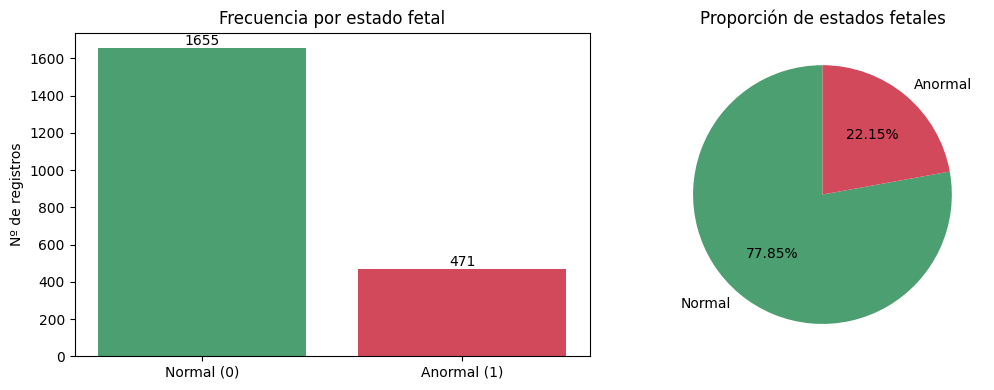

In [5]:
# Visualización de la proporción
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].bar(['Normal (0)', 'Anormal (1)'], conteo.values, color=['#4C9F70', '#D1495B'])
ax[0].set_title('Frecuencia por estado fetal')
ax[0].set_ylabel('Nº de registros')
for i, v in enumerate(conteo.values):
    ax[0].text(i, v + 15, str(v), ha='center')

ax[1].pie(conteo.values, labels=['Normal', 'Anormal'], autopct='%1.2f%%',
          colors=['#4C9F70', '#D1495B'], startangle=90)
ax[1].set_title('Proporción de estados fetales')

plt.tight_layout()
plt.show()

**Lo que veo aquí.** Las dos clases no están equilibradas. Alrededor del 77,85 % de los registros
(1655 casos) son de estado fetal normal, mientras que solo el 22,15 % (471 casos) son anormales.
Este tipo de desbalance es muy típico en datos clínicos, y conviene no perderlo de vista porque,
si más adelante entrenamos un modelo de clasificación, puede condicionar sus resultados.


## 4. Medidas de centralización, localización y dispersión

Para tres variables concretas —`FM`, `ALTV` y `Median`— voy a calcular un resumen numérico
completo, agrupado en tres bloques:

- **Centralización:** media, mediana y moda.
- **Localización:** mínimo, máximo, los cuartiles (Q1, Q2, Q3) y los percentiles P10 y P90.
- **Dispersión:** rango, rango intercuartílico (IQR), varianza, desviación típica y coeficiente
  de variación (CV).


In [6]:
variables = ['FM', 'ALTV', 'Median']

def medidas(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return pd.Series({
        # Centralización
        'media':        s.mean(),
        'mediana':      s.median(),
        'moda':         s.mode().iloc[0],
        # Localización
        'minimo':       s.min(),
        'maximo':       s.max(),
        'Q1 (P25)':     q1,
        'Q2 (P50)':     s.quantile(0.50),
        'Q3 (P75)':     q3,
        'P10':          s.quantile(0.10),
        'P90':          s.quantile(0.90),
        # Dispersión
        'rango':        s.max() - s.min(),
        'IQR':          q3 - q1,
        'varianza':     s.var(),
        'desv_tipica':  s.std(),
        'CV (%)':       s.std() / s.mean() * 100,
    })

resumen = df[variables].apply(medidas).round(3)
resumen

,FM,ALTV,Median
media,7.241,9.847,138.090
mediana,0.000,0.000,139.000
moda,0.000,0.000,146.000
minimo,0.000,0.000,77.000
maximo,564.000,91.000,186.000
Q1 (P25),0.000,0.000,129.000
Q2 (P50),0.000,0.000,139.000
Q3 (P75),2.000,11.000,148.000
P10,0.000,0.000,120.000
P90,9.000,38.000,155.000


**Lo que veo aquí.**

- **`FM` (movimientos fetales).** Aunque la media sale en torno a 7,24, tanto la mediana como la
  moda valen 0, lo que significa que en más de la mitad de los registros no hay ningún movimiento
  fetal. La distribución se va claramente hacia la derecha (llega hasta 564) y su dispersión es
  enorme (CV cercano al 513 %), lo que ya avisa de que hay valores atípicos muy altos.
- **`ALTV` (% de tiempo con variabilidad de largo plazo anormal).** Se comporta parecido: mediana
  y moda a 0, media alrededor de 9,85 y máximo de 91. El 75 % de los casos queda por debajo del 11 %,
  pero arrastra una cola hacia valores altos (CV en torno al 187 %).
- **`Median` (mediana del histograma de FCF).** De las tres es la más simétrica y tranquila: la media
  ronda 138,1 y la mediana es 139, ambas dentro del rango fisiológico normal de la frecuencia cardíaca
  fetal (110–160 lpm). Su dispersión es moderada (CV de solo un 10,5 %).


## 5. Histogramas de `LBE`, `DS` y `Min`

Un histograma sirve para ver de un vistazo cómo se reparten los valores de una variable, es decir,
su distribución de frecuencias. Dibujo uno para cada una de estas tres variables.


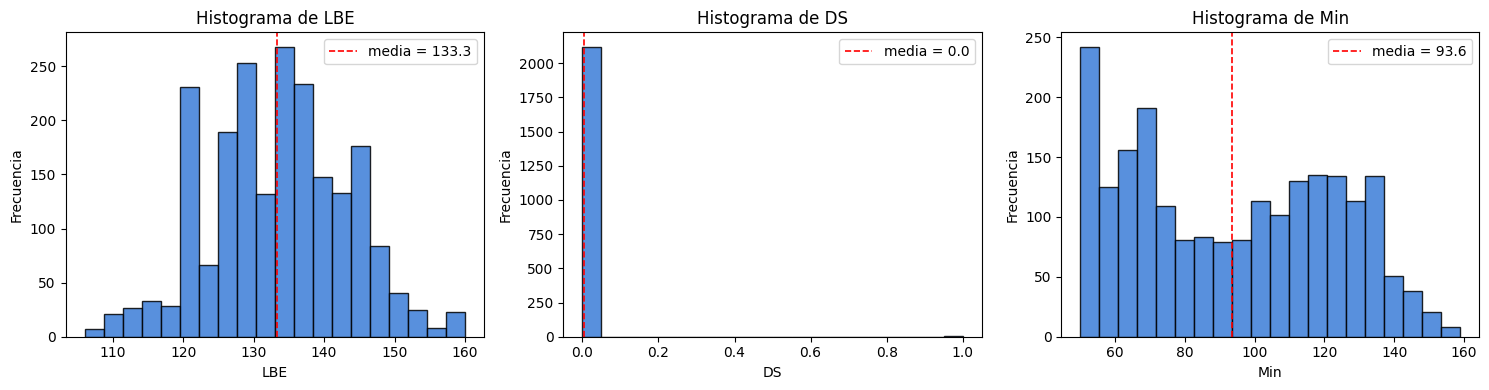

In [7]:
hist_vars = ['LBE', 'DS', 'Min']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, hist_vars):
    ax.hist(df[col], bins=20, color='#3B7DD8', edgecolor='black', alpha=0.85)
    ax.set_title(f'Histograma de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2,
               label=f'media = {df[col].mean():.1f}')
    ax.legend()

plt.tight_layout()
plt.show()

**Lo que veo aquí.**

- **`LBE` (línea base de FCF).** Sale una distribución más o menos simétrica y con forma de campana,
  centrada alrededor de 130–140 lpm, que encaja con lo que sería una frecuencia cardíaca fetal normal.
- **`DS` (deceleraciones severas).** Casi todos los valores son 0: las deceleraciones severas apenas
  aparecen, son un evento rarísimo. Por eso el histograma es prácticamente un único pico enorme en 0.
- **`Min` (mínimo del histograma de FCF).** Aquí la distribución es algo asimétrica, con la mayoría de
  los valores agrupados en la parte media-baja de la frecuencia cardíaca.


## 6. Diagramas de caja (box-plot) de `AC`, `ASTV` y `Mean`

El box-plot resume una distribución a partir de sus cuartiles: la caja va de Q1 a Q3 y la línea
de dentro es la mediana. Los bigotes se extienden hasta 1,5·IQR, y los puntos que quedan fuera de
ellos se consideran valores atípicos. Lo dibujo para estas tres variables.


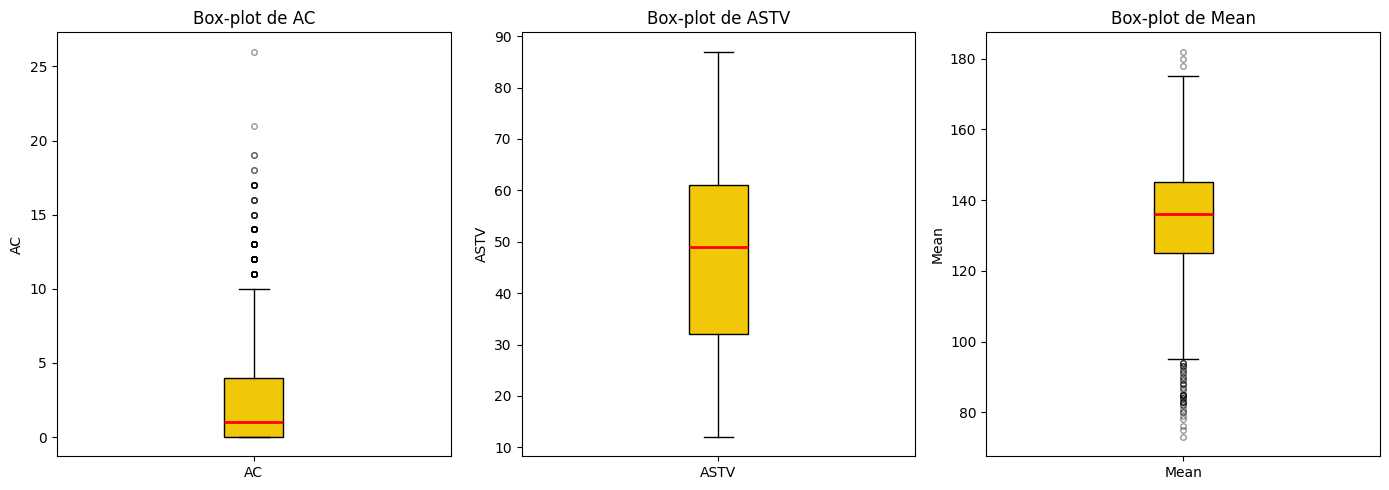

In [8]:
box_vars = ['AC', 'ASTV', 'Mean']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, box_vars):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='#F0C808', color='black'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markersize=4, alpha=0.4))
    ax.set_title(f'Box-plot de {col}')
    ax.set_ylabel(col)
    ax.set_xticks([1])
    ax.set_xticklabels([col])

plt.tight_layout()
plt.show()

In [9]:
# Detalle numérico de cada box-plot (cuartiles y límites de atípicos)
detalle = []
for col in box_vars:
    s = df[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_atip = ((s < lim_inf) | (s > lim_sup)).sum()
    detalle.append([col, q1, s.median(), q3, iqr, lim_inf, lim_sup, n_atip])

pd.DataFrame(detalle, columns=['var', 'Q1', 'mediana', 'Q3', 'IQR',
                               'lim_inf', 'lim_sup', 'n_atipicos'])

,var,Q1,mediana,Q3,IQR,lim_inf,lim_sup,n_atipicos
0,AC,0.0,1.0,4.0,4.0,-6.0,10.0,83
1,ASTV,32.0,49.0,61.0,29.0,-11.5,104.5,0
2,Mean,125.0,136.0,145.0,20.0,95.0,175.0,45


**Lo que veo aquí.**

- **`AC` (aceleraciones).** La caja queda muy pegada a 0 y aparecen muchísimos atípicos por arriba:
  casi todos los registros tienen pocas aceleraciones y unos pocos tienen muchas, así que la
  distribución se va hacia la derecha.
- **`ASTV` (% de variabilidad de corto plazo anormal).** Es la más repartida y simétrica de las tres.
  La caja cubre un rango amplio de porcentajes y prácticamente no genera valores atípicos.
- **`Mean` (media del histograma de FCF).** Caja estrecha situada en la zona fisiológica normal
  (más o menos 130–140 lpm), pero con atípicos por los dos lados, que se corresponderían con
  bradicardias y taquicardias puntuales.


## Conclusiones

Después de recorrer todo el análisis, saco estas ideas principales:

- El dataset tiene 2126 registros y 26 variables, y no falta ningún valor.
- La mayoría de las variables son cuantitativas discretas (recuentos y valores de FCF en lpm);
  unas pocas son continuas (los porcentajes y promedios de variabilidad) y hay dos cualitativas,
  `Tendency` (ordinal) y `Target` (nominal).
- Los estados fetales están desbalanceados: hay muchos más normales (77,85 %) que anormales (22,15 %).
- Las variables que cuentan eventos, como `FM`, `AC`, `DS` o `ALTV`, están muy sesgadas hacia la
  derecha y llenas de atípicos (muchos ceros y unos pocos valores muy grandes). En cambio, las que
  describen la frecuencia cardíaca (`Median`, `Mean`, `LBE`) son más estables y se mantienen cerca
  del rango fisiológico normal.
